In [9]:
# dashboard_jupyter.py - uruchom w Jupyterze
import matplotlib.pyplot as plt
from collections import deque
import json
from kafka import KafkaConsumer
import threading
from datetime import datetime
import numpy as np
from IPython.display import clear_output
import time

BROKER = 'broker:9092'

# Przechowywanie danych
readings = deque(maxlen=50)
alerts = deque(maxlen=10)
sensor_data = {}

def konsument():
    try:
        consumer = KafkaConsumer(
            'sensor_readings', 'alerts',
            bootstrap_servers=BROKER,
            auto_offset_reset='latest',
            value_deserializer=lambda x: json.loads(x.decode('utf-8'))
        )
        for msg in consumer:
            data = msg.value
            data['timestamp'] = datetime.now()
            if msg.topic == 'sensor_readings':
                readings.append(data)
                sensor_data[data.get('sensor_id')] = data.get('pm25', 0)
            else:
                alerts.append(data)
    except Exception as e:
        print(f"Błąd Kafki: {e}")

# Uruchom konsumenta w tle
thread = threading.Thread(target=konsument, daemon=True)
thread.start()

print("Dashboard uruchomiony")
print("="*60)

Dashboard uruchomiony


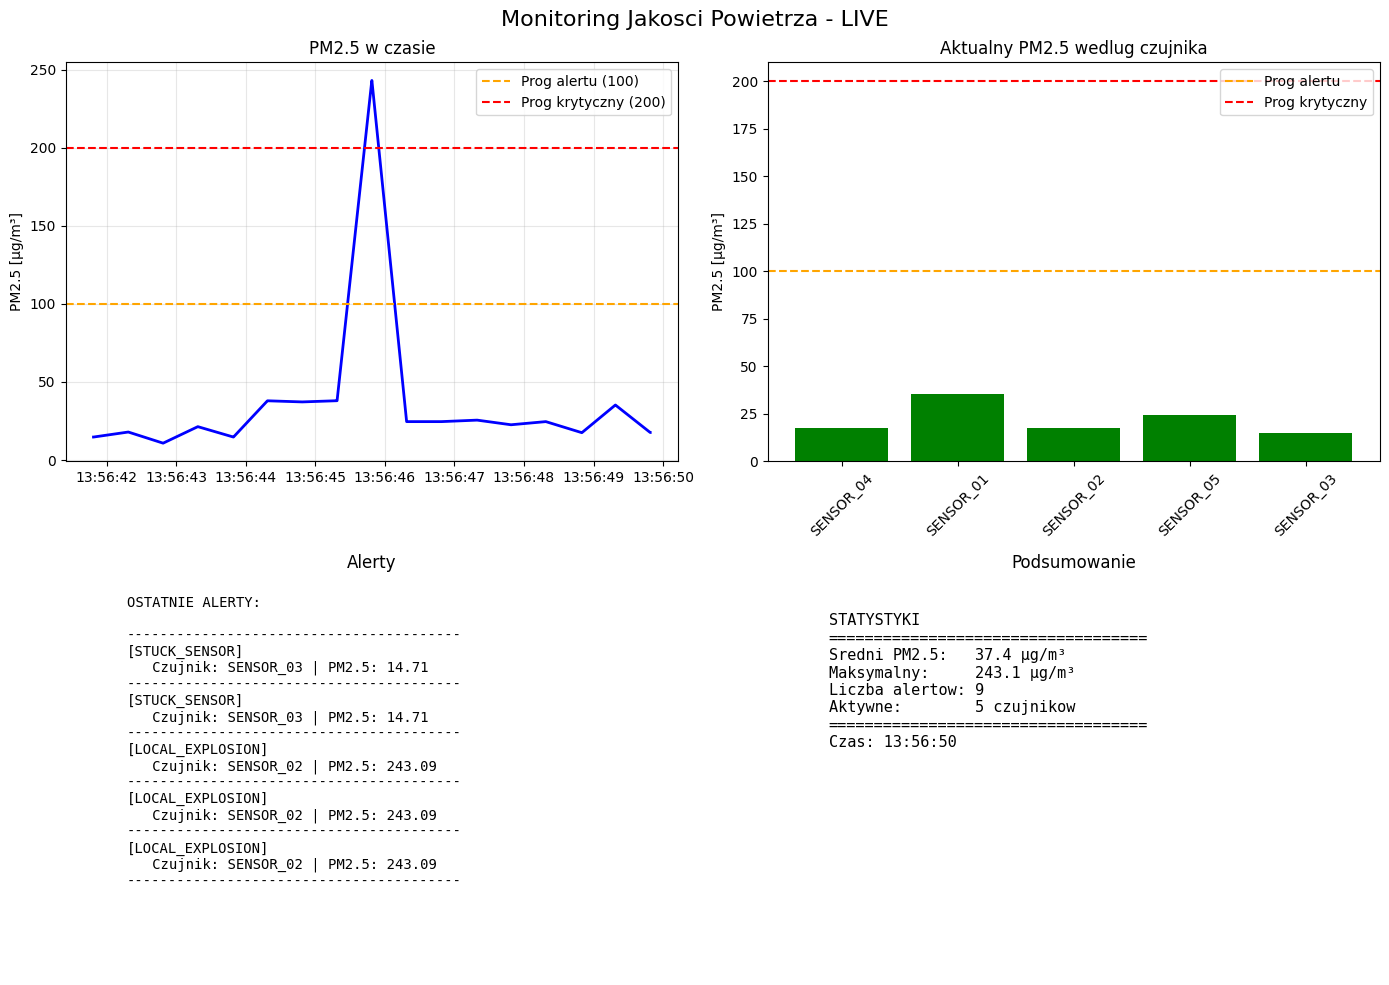

KeyboardInterrupt: 

In [10]:
from IPython.display import clear_output
import time

while True:
    clear_output(wait=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Monitoring Jakosci Powietrza - LIVE', fontsize=16)
    
    # ===== 1. PM2.5 w czasie =====
    if readings:
        times = [r['timestamp'] for r in readings]
        pm25_vals = [r.get('pm25', 0) for r in readings]
        axes[0,0].plot(times, pm25_vals, 'b-', linewidth=2)
        axes[0,0].axhline(y=100, color='orange', linestyle='--', label='Prog alertu (100)')
        axes[0,0].axhline(y=200, color='red', linestyle='--', label='Prog krytyczny (200)')
        axes[0,0].set_ylabel('PM2.5 [µg/m³]')
        axes[0,0].set_title('PM2.5 w czasie')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
    
    # ===== 2. Aktualne wartości czujników =====
    if sensor_data:
        sensors = list(sensor_data.keys())
        values = list(sensor_data.values())
        colors = ['red' if v > 200 else 'orange' if v > 100 else 'green' for v in values]
        axes[0,1].bar(sensors, values, color=colors)
        axes[0,1].axhline(y=100, color='orange', linestyle='--', label='Prog alertu')
        axes[0,1].axhline(y=200, color='red', linestyle='--', label='Prog krytyczny')
        axes[0,1].set_ylabel('PM2.5 [µg/m³]')
        axes[0,1].set_title('Aktualny PM2.5 wedlug czujnika')
        axes[0,1].tick_params(axis='x', rotation=45)
        axes[0,1].legend()
    
    # ===== 3. Alerty =====
    axes[1,0].axis('off')
    if alerts:
        alert_text = "OSTATNIE ALERTY:\n" + "\n" + "-" * 40 + "\n"
        for a in list(alerts)[-5:]:
            alert_type = a.get('alert_type', 'UNKNOWN')
            sensor_id = a.get('sensor_id', '?')
            pm25 = a.get('pm25', '?')
            alert_text += f"[{alert_type}]\n   Czujnik: {sensor_id} | PM2.5: {pm25}\n" + "-" * 40 + "\n"
        axes[1,0].text(0.1, 0.95, alert_text, fontsize=10, verticalalignment='top', family='monospace')
    else:
        axes[1,0].text(0.1, 0.5, "BRAK ALERTOW", fontsize=14, ha='center', color='green')
    axes[1,0].set_title('Alerty')
    
    # ===== 4. Statystyki =====
    axes[1,1].axis('off')
    if readings:
        pm25_vals = [r.get('pm25', 0) for r in readings]
        stats = f"""
STATYSTYKI
{'=' * 35}
Sredni PM2.5:   {np.mean(pm25_vals):.1f} µg/m³
Maksymalny:     {max(pm25_vals):.1f} µg/m³
Liczba alertow: {len(alerts)}
Aktywne:        {len(sensor_data)} czujnikow
{'=' * 35}
Czas: {datetime.now().strftime('%H:%M:%S')}
        """
        axes[1,1].text(0.1, 0.95, stats, fontsize=11, verticalalignment='top', family='monospace')
    axes[1,1].set_title('Podsumowanie')
    
    plt.tight_layout()
    plt.show()
    
    time.sleep(0.5)  # czekaj 0.5 sekundy przed kolejnym odświeżeniem